In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 1. Le o JSON
df = pd.read_json('resultados_finais.json')

# 2. Processa as métricas da AWS do simulador
# Soma os tokens de entrada e saída para ter o gasto total
df['Tokens_Usados'] = df['tokens_in_total'] + df['tokens_out_total']
# Converte a latência de milissegundos para segundos
df['Tempo_Segundos'] = df['latencia_media_ms'] / 1000 

# 3. Configura o visual dos gráficos
sns.set_theme(style="whitegrid")
cores = {"zero_shot": "#e74c3c", "cot": "#3498db", "self_consistency": "#2ecc71"}

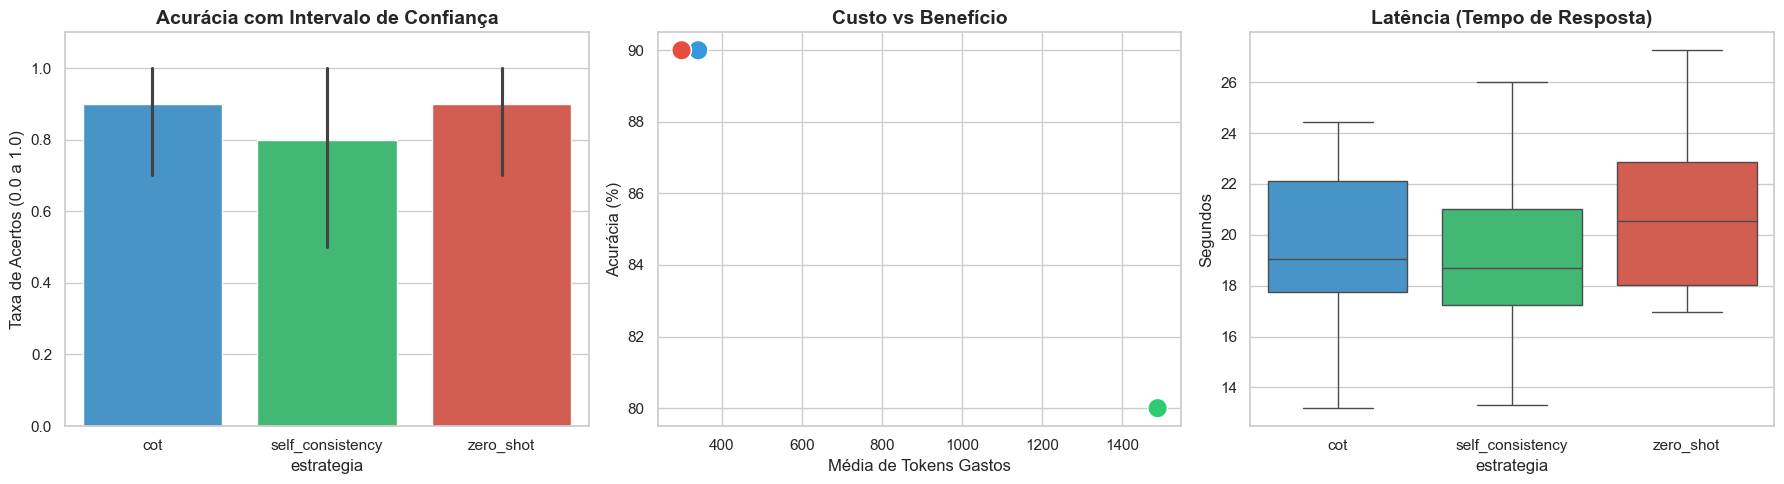

In [3]:
# Cria o painel com os 3 gráficos side-by-side
fig, eixos = plt.subplots(1, 3, figsize=(18, 5))

# GRÁFICO 1: ACURÁCIA (Com Intervalo de Confiança / Bootstrap)
sns.barplot(x='estrategia', y='acertou', hue='estrategia', data=df, palette=cores, ax=eixos[0], errorbar=('ci', 95), legend=False)
eixos[0].set_title('Acurácia com Intervalo de Confiança', fontsize=14, fontweight='bold')
eixos[0].set_ylabel('Taxa de Acertos (0.0 a 1.0)')
eixos[0].set_ylim(0, 1.1)

# Cálculos para o Gráfico de Custo vs Benefício
acuracia = df.groupby('estrategia')['acertou'].mean() * 100
custo_medio = df.groupby('estrategia')['Tokens_Usados'].mean()

# GRÁFICO 2: CUSTO VS BENEFÍCIO
sns.scatterplot(x=custo_medio.values, y=acuracia.values, hue=acuracia.index, 
                palette=cores, s=200, ax=eixos[1], legend=False)
eixos[1].set_title('Custo vs Benefício', fontsize=14, fontweight='bold')
eixos[1].set_xlabel('Média de Tokens Gastos')
eixos[1].set_ylabel('Acurácia (%)')

# GRÁFICO 3: LATÊNCIA
sns.boxplot(x='estrategia', y='Tempo_Segundos', hue='estrategia', data=df, palette=cores, ax=eixos[2], legend=False)
eixos[2].set_title('Latência (Tempo de Resposta)', fontsize=14, fontweight='bold')
eixos[2].set_ylabel('Segundos')

# Mostra o painel final
plt.tight_layout()
plt.show()